In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [2]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *  

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='create.tcl',
                output_file='create',
                prefix="ops")

In [5]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (147875824635)>


In [6]:
ops.wipe()

# User-defined variables
massDen = 2.0
massProportionalDamping = 0.0
InitStiffnessProportionalDamping = 0.001
fangle = 31.40
ptangle = 26.50
E = 90000.0
poisson = 0.40
G = E / (2 * (1 + poisson))
B = E / (3 * (1 - 2 * poisson))
press = 0.0
deltaT = 0.010
numSteps = 500
gamma = 0.500
period = 1
pi = math.pi
inclination = 0
unitWeightX = massDen * 9.81 * math.sin(inclination / 180.0 * pi)
unitWeightY = -massDen * 9.81 * math.cos(inclination / 180.0 * pi)
loadIncr = 1.0

matOpt = 1  # 1 = pressure depend; 2 = pressure independ
fmass = 1.0  # fluid mass density
smass = 2.0  # saturated soil mass density
G = 6.0e4
B = 2.4e5
bulk = 2.2e6  # fluid-solid combined bulk modulus
vperm = 5.0e-4  # vertical permeability (m/s)
hperm = 5.0e-4  # horizontal permeability (m/s)
accGravity = 9.81  # acceleration of gravity

# Actual values used in computation
vperm = vperm / accGravity / fmass
hperm = hperm / accGravity / fmass


# Model builder
ops.model('basic', '-ndm', 2, '-ndf', 3)

# Define material
#PressureDependMultiYield', matTag, nd, rho, refShearModul, refBulkModul, frictionAng, 
#peakShearStra, refPress, pressDependCoe, PTAng, contrac, *dilat, *liquefac, noYieldSurf=20.0, *yieldSurf=[], e=0.6, *params=[0.9, 0.02, 0.7, 101.0], c=0.3)
# ops.nDMaterial('PressureDependMultiYield', 
# 2, #matTag
# 2, #nd
# massDen,#rho
# G,#refShearModul
# B,#refBulkModul
# fangle,#frictionAng
# 0.1,#peakShearStra
# 80,#refPress
# 0.5,#pressDependCoe
# ptangle,#PTAng
# 0.17,#contrac
# 0.4,#*dilat
# 10,#*liquefac
# 0, #noYieldSurf=20.0
# 0.015,
# 1.0)
fangle = 32.0
ops.nDMaterial(
    "PressureDependMultiYield02", 
    2,#mtag
    2, #nd
    1.8,#rho
    90000.0,#refShearModul
    220000.0,#refBulkModul
    fangle,#frictionAng
    0.1,#peakShearStra
    80,#refPress
    0.5,#pressDependCoe
    26.0,#phaseTransformAngle
    0.067,#contractionParam1
    0.23,#contractionParam3
    0.06,#dilationParam1
    0.27 #dilationParam3
)

# Define nodes
ops.node(1, 0.0, 0.0)
ops.node(2, 1.0, 0.0)
ops.node(3, 1.0, 1.0)
ops.node(4, 0.0, 1.0)

loadBias = 0.07 
gravY = -accGravity  # calc. gravity
gravX = -gravY * loadBias
# Define element
#ops.element('quad', 1, 1, 2, 3, 4, 1.0, 'PlaneStrain', 2, press, 0.0, unitWeightX, unitWeightY)
ops.element("quadUP", 1, 1, 2, 3, 4, 1.0, 2, bulk, fmass, hperm, vperm, gravX, gravY, press)
# Initial elastic stage
ops.updateMaterialStage('-material', 2, '-stage', 0)

# Boundary conditions
ops.fix(1, 1, 1, 1)
ops.fix(2, 1, 1, 1)
ops.equalDOF(3, 4, 1, 2)

# Gravity load application
ops.system('ProfileSPD')
ops.test('NormDispIncr', 1e-12, 25, 0)
ops.constraints('Transformation')
ops.integrator('LoadControl', 1, 1, 1, 1)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.analysis('Static')
ops.analyze(2)

newBulk = G * 2 / 3
fos = 1.01
newfangle = fangle / fos
# --- switch the material to plastic ---
# switch material in Python

ops.parameter(1001, 'element', 1, "bulkModulus", '2')

ops.parameter(1002, 'element', 1, "frictionAngle", '2')

# Switch to plastic stage
ops.updateMaterialStage('-material', 2, '-stage', 1)
#ops.updateParameter(1001, newBulk) 
#ops.updateParameter(1002, newfangle) 

ops.analyze(1)


ProfileSPDLinDirectSolver::solve() -  aii < 0 (i, aii): (0,0)
WARNING NewtonRaphson::solveCurrentStep() -the LinearSysOfEqn failed in solve()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 1
OpenSees > analyze failed, returned: -3 error flag
ProfileSPDLinDirectSolver::solve() -  aii < 0 (i, aii): (0,0)
WARNING NewtonRaphson::solveCurrentStep() -the LinearSysOfEqn failed in solve()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 1
OpenSees > analyze failed, returned: -3 error flag


-3

In [7]:
ops.printModel()

Current Domain Information
	Current Time: 0
	Committed Time: 0
NODE DATA: NumNodes: 4

numComponents: 4

 Node: 1
	Coordinates  : 0 0 
	Disps: 0 0 0 
	 unbalanced Load: 0 0 0 
	ID : -1 -1 -1 


 Node: 2
	Coordinates  : 1 0 
	Disps: 0 0 0 
	 unbalanced Load: 0 0 0 
	ID : -1 -1 -1 


 Node: 3
	Coordinates  : 1 1 
	Disps: 0 0 0 
	 unbalanced Load: 0 0 0 
	ID : 1 2 3 


 Node: 4
	Coordinates  : 0 1 
	Disps: 0 0 0 
	 unbalanced Load: 0 0 0 
	ID : 0 1 2 

ELEMENT DATA: NumEle: 1

numComponents: 1

FourNodeQuadUP, element id:  1
	Connected external nodes:  1 2 3 4 
	thickness:  1
	mass density:  1
	surface pressure:  0
	body forces:  0.6867 -9.81
PressureDependMultiYield02
	Stress (xx yy xy)
		Gauss point 1: 0 0 0 
		Gauss point 2: 0 0 0 
		Gauss point 3: 0 0 0 
		Gauss point 4: 0 0 0 

SP_Constraints: numConstraints: 6

numComponents: 6
SP_Constraint: 0	 Node: 1 DOF: 1 ref value: 0 current value: 0 initial value: 0
SP_Constraint: 1	 Node: 1 DOF: 2 ref value: 0 current value: 0 initial value:

In [8]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [ ]:
# Apply pushover load
ops.setTime(0.0)
ops.wipeAnalysis()
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
ops.load(3, loadIncr, 0.0, 0.0)

# Recorders
ops.recorder('Node', '-file', 'fdisp.out', '-time', '-node', *[1, 2, 3, 4], '-dof', 1, 2, '-dT', 0.01, 'disp')
ops.recorder('Node', '-file', 'facce.out', '-time', '-node', *[1, 2, 3, 4], '-dof', 1, 2, '-dT', 0.01, 'accel')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'fstress1.out', '-dT', 0.01, 'material', 1, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'fstrain1.out', '-dT', 0.01, 'material', 1, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'fstress3.out', '-dT', 0.01, 'material', 3, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'fstrain3.out', '-dT', 0.01, 'material', 3, 'strain')

# Static analysis for pushover
ops.constraints('Transformation')
ops.test('NormDispIncr', 1e-12, 25, 0)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.system('ProfileSPD')
ops.rayleigh(massProportionalDamping, 0.0, InitStiffnessProportionalDamping, 0.0)
ops.integrator('Newmark', gamma, (gamma + 0.5)**2 / 4)
ops.analysis('VariableTransient')

startT = tt.time()
ops.analyze(numSteps, deltaT, deltaT / 100, deltaT, 10)
endT = tt.time()

ops.wipe()

ProfileSPDLinDirectSolver::solve() -  aii < 0 (i, aii): (0,0)
WARNING NewtonRaphson::solveCurrentStep() -the LinearSysOfEqn failed in solve()
ProfileSPDLinDirectSolver::solve() -  aii < 0 (i, aii): (0,0)
WARNING NewtonRaphson::solveCurrentStep() -the LinearSysOfEqn failed in solve()
ProfileSPDLinDirectSolver::solve() -  aii < 0 (i, aii): (0,0)
WARNING NewtonRaphson::solveCurrentStep() -the LinearSysOfEqn failed in solve()
ProfileSPDLinDirectSolver::solve() -  aii < 0 (i, aii): (0,0)
WARNING NewtonRaphson::solveCurrentStep() -the LinearSysOfEqn failed in solve()
ProfileSPDLinDirectSolver::solve() -  aii < 0 (i, aii): (0,0)
WARNING NewtonRaphson::solveCurrentStep() -the LinearSysOfEqn failed in solve()
ProfileSPDLinDirectSolver::solve() -  aii < 0 (i, aii): (0,0)
WARNING NewtonRaphson::solveCurrentStep() -the LinearSysOfEqn failed in solve()
ProfileSPDLinDirectSolver::solve() -  aii < 0 (i, aii): (0,0)
WARNING NewtonRaphson::solveCurrentStep() -the LinearSysOfEqn failed in solve()
Profil

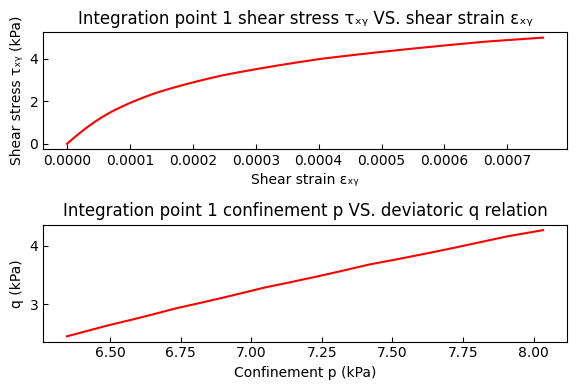

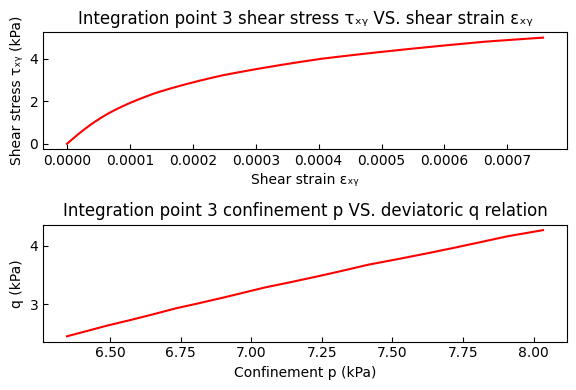

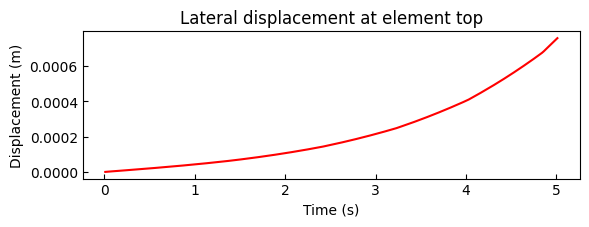

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
a1 = np.loadtxt('facce.out')
d1 = np.loadtxt('fdisp.out')
s1 = np.loadtxt('fstress1.out')
e1 = np.loadtxt('fstrain1.out')
s5 = np.loadtxt('fstress3.out')
e5 = np.loadtxt('fstrain3.out')

# Approximate MATLAB paperposition as figure size
figsize = (6, 4)

def compute_p_q(stress):
    """Compute confinement p (po) and deviatoric stress q (qo)."""
    po = np.mean(stress[:, 1:4], axis=1)
    qo = []
    for i in range(len(stress)):
        q = ((stress[i,1] - stress[i,2])**2 +
             (stress[i,2] - stress[i,3])**2 +
             (stress[i,1] - stress[i,3])**2 +
             6.0 * stress[i,4]**2)
        q = np.sign(stress[i,4]) * (1/3.0) * np.sqrt(q)
        qo.append(q)
    return po, np.array(qo)

# --- Integration Point 1 ---
po1, qo1 = compute_p_q(s1)

plt.figure(1, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(e1[:,3], s1[:,4], 'r')
plt.title('Integration point 1 shear stress τₓᵧ VS. shear strain εₓᵧ')
plt.xlabel('Shear strain εₓᵧ')
plt.ylabel('Shear stress τₓᵧ (kPa)')

plt.subplot(2,1,2)
plt.plot(-po1, qo1, 'r')
plt.title('Integration point 1 confinement p VS. deviatoric q relation')
plt.xlabel('Confinement p (kPa)')
plt.ylabel('q (kPa)')

plt.tight_layout()
plt.savefig('SS_PQ1.jpg')
plt.show()

# --- Integration Point 3 ---
po3, qo3 = compute_p_q(s5)

plt.figure(4, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(e5[:,3], s5[:,4], 'r')
plt.title('Integration point 3 shear stress τₓᵧ VS. shear strain εₓᵧ')
plt.xlabel('Shear strain εₓᵧ')
plt.ylabel('Shear stress τₓᵧ (kPa)')

plt.subplot(2,1,2)
plt.plot(-po3, qo3, 'r')
plt.title('Integration point 3 confinement p VS. deviatoric q relation')
plt.xlabel('Confinement p (kPa)')
plt.ylabel('q (kPa)')

plt.tight_layout()
plt.savefig('SS_PQ5.jpg')
plt.show()

# --- Displacement ---
plt.figure(2, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(d1[:,0], d1[:,5], 'r')  # MATLAB col 6 → Python col index 5
plt.title('Lateral displacement at element top')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')

plt.tight_layout()
plt.savefig('D.jpg')
plt.show()
